# Dataset links:
1. https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
2. https://www.kaggle.com/datasets/stealthtechnologies/employee-attrition-dataset

# Discussions

1. How do we use Gen-AI in this project? (Code plugin) - Done by Xiwen & Aaron
	- RAG (broadbased recommendation?)
		- Scrape or get the best practices from top companies
		- Use the information to form the knowledge base for the LLM
		- Use the LLM to perform broadbased recommendation based on the parameters of the group of employees. 
2. EDA & Features - Done by Shenghao
	- Feature selection  (Domain knowledge)
	- Dimension reduction? - Done by
3. Classification / NN-DL - Done by Jia Hong & Kelda
	- Train a few ensemble models and stack the best 2-3? 
	- Hyper-param tuning 
	- NN / DL: Are we gonna use supervised learning or NN/DL
4. Deployment - Done by Alexander
	- Streamlit
	- FastAPI
5. Report structre - Done by Kelda
6. Presentation structure - Done by Jia Hong
7. Report + Presentation content - By Everyone


# Tentative deadline: (Main project deadline: 7th November 6.30pm)
- Best practices from top companies (Research) : 27 Oct
- Feature selection : 27 Oct
- Classification : 1 Nov
- Gen-AI RAG : 1 Nov
- Deployment : 3 Nov
- Draft report + presentation : 5 Nov
- Report + presentation : 6 Nov

In [ ]:
%pip install matplotlib seaborn pandas numpy openai scikit-learn fastapi streamlit dotenv pydantic requests
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
%pip install langchain-core langchain-openai langgraph 
%pip install langchain

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from openai import OpenAI
from pydantic import BaseModel

In [8]:
# load OpenAI API key


OPENAI_API_KEY = ''
try:
	from google.colab import userdata
	print("Running in Google Colab")
	OPENAI_API_KEY = userdata.get('OPENAI_API_KEY', '')
except ImportError:
	import dotenv
	dotenv.load_dotenv()
	print("Running locally")
	OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')

openai = OpenAI(api_key=OPENAI_API_KEY)
try:
	response = openai.models.list()
	print("Available models:", response.data)
	print("OpenAI API key is valid.")
except Exception as e:
	print("Error with OpenAI API key:", e)

Running locally
Available models: [Model(id='gpt-4o-mini', created=1721172741, object='model', owned_by='system'), Model(id='gpt-4o-mini-realtime-preview', created=1734387380, object='model', owned_by='system'), Model(id='gpt-4o-mini-search-preview', created=1741391161, object='model', owned_by='system'), Model(id='gpt-5-nano', created=1754426384, object='model', owned_by='system'), Model(id='text-embedding-ada-002', created=1671217299, object='model', owned_by='openai-internal')]
OpenAI API key is valid.


In [9]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


# Feature selection

In [10]:
from sklearn.calibration import LabelEncoder


print("="*60)
print("STEP 1: IDENTIFY AND REMOVE CONSTANT FEATURES")
print("="*60)

# Check for constant features (zero variance)
constant_features = []
for col in df.columns:
    if df[col].nunique() == 1:
        constant_features.append(col)
        print(f"Constant feature found: {col} (unique values: {df[col].nunique()})")

# Remove constant features
df_clean = df.drop(columns=constant_features)
print(f"\nRemoved {len(constant_features)} constant features")
print(f"Remaining columns: {df_clean.shape[1]}")

# Separate target and features
target = 'Attrition'
X = df_clean.drop(columns=[target])
y = df_clean[target]

# Encode target variable (Yes/No to 1/0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nTarget classes: {le.classes_}")
print(f"Class distribution:\n{pd.Series(y_encoded).value_counts()}")

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

STEP 1: IDENTIFY AND REMOVE CONSTANT FEATURES
Constant feature found: EmployeeCount (unique values: 1)
Constant feature found: Over18 (unique values: 1)
Constant feature found: StandardHours (unique values: 1)

Removed 3 constant features
Remaining columns: 32

Target classes: ['No' 'Yes']
Class distribution:
0    1233
1     237
Name: count, dtype: int64

Numeric features: 24
Categorical features: 7



STEP 2: CORRELATION ANALYSIS (Remove Highly Correlated Features)

Highly correlated feature pairs (|correlation| > 0.9):
  JobLevel <-> MonthlyIncome: 0.950


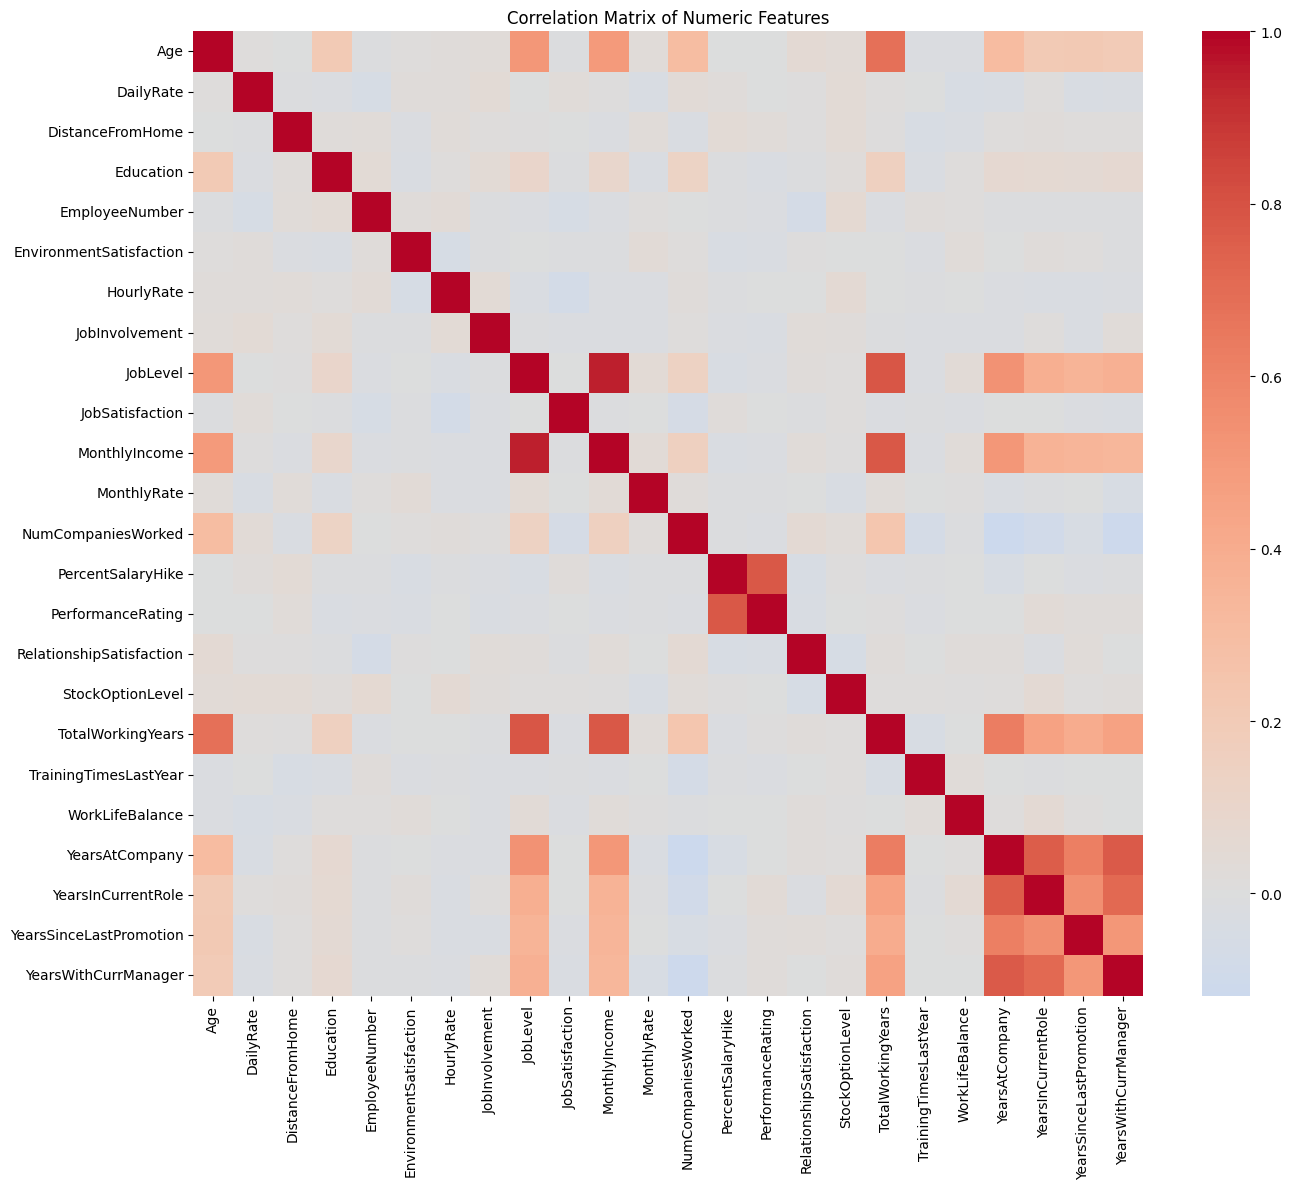

In [12]:
import seaborn as sns
print("\n" + "="*60)
print("STEP 2: CORRELATION ANALYSIS (Remove Highly Correlated Features)")
print("="*60)

# Check correlation among numeric features
correlation_matrix = X[numeric_features].corr()

# Find highly correlated pairs (correlation > 0.9)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print("\nHighly correlated feature pairs (|correlation| > 0.9):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("No highly correlated features found")

# Plot correlation heatmap for numeric features
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


STEP 3: UNIVARIATE FEATURE SELECTION (Mutual Information)

Top 15 features by Mutual Information:
                    feature  mi_score
16            MonthlyIncome  0.033371
13                  JobRole  0.024137
19                 OverTime  0.023896
12                 JobLevel  0.021957
15            MaritalStatus  0.021635
0                       Age  0.019615
24        TotalWorkingYears  0.017539
1            BusinessTravel  0.017314
9                    Gender  0.016276
29  YearsSinceLastPromotion  0.013445
20        PercentSalaryHike  0.013265
23         StockOptionLevel  0.011836
25    TrainingTimesLastYear  0.010202
28       YearsInCurrentRole  0.010017
11           JobInvolvement  0.009972


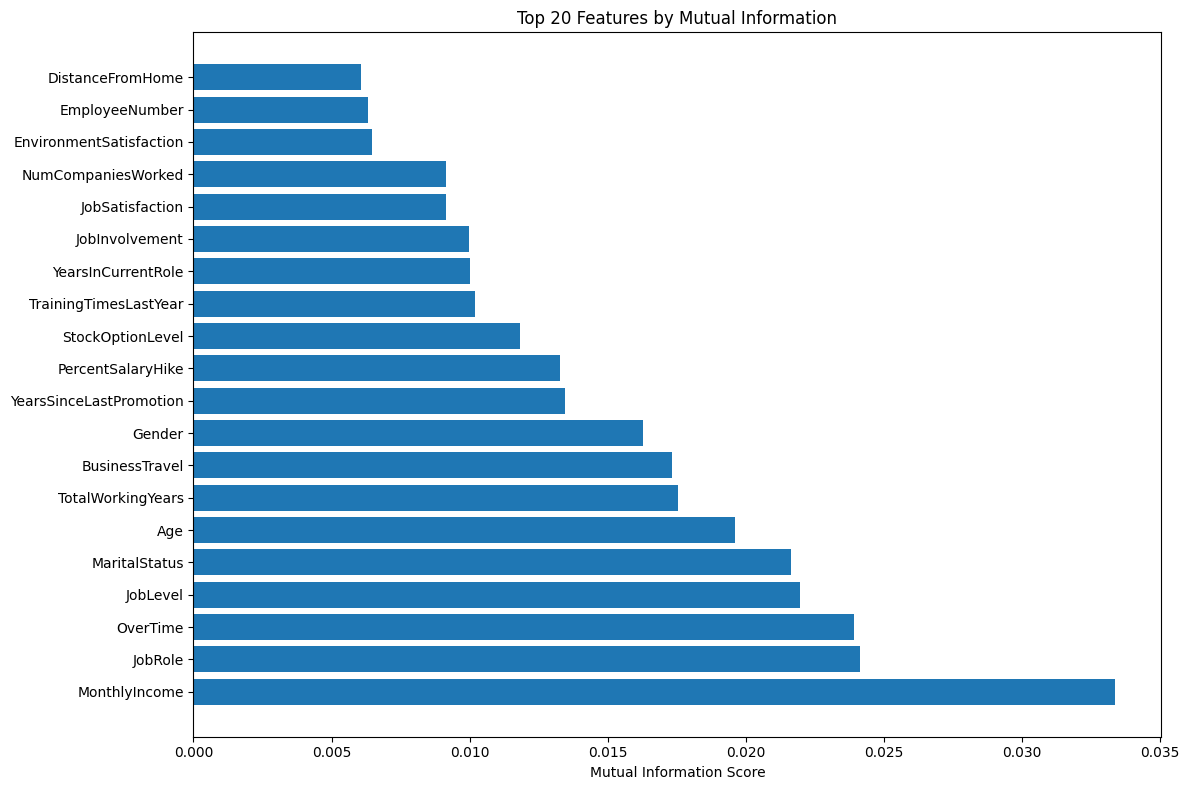

In [13]:
from sklearn.feature_selection import mutual_info_classif


print("\n" + "="*60)
print("STEP 3: UNIVARIATE FEATURE SELECTION (Mutual Information)")
print("="*60)

# For categorical features, encode them first
X_encoded = X.copy()
label_encoders = {}
for col in categorical_features:
    le_temp = LabelEncoder()
    X_encoded[col] = le_temp.fit_transform(X[col])
    label_encoders[col] = le_temp

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_encoded, y_encoded, random_state=42)
mi_scores_df = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 15 features by Mutual Information:")
print(mi_scores_df.head(15))

# Visualize
plt.figure(figsize=(12, 8))
plt.barh(mi_scores_df['feature'].head(20), mi_scores_df['mi_score'].head(20))
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features by Mutual Information')
plt.tight_layout()
plt.show()


STEP 4: TREE-BASED FEATURE IMPORTANCE

Top 15 features by Random Forest Importance:
                    feature  importance
16            MonthlyIncome    0.074180
0                       Age    0.066742
24        TotalWorkingYears    0.061116
2                 DailyRate    0.049100
7            EmployeeNumber    0.047631
19                 OverTime    0.046899
4          DistanceFromHome    0.046419
17              MonthlyRate    0.045094
27           YearsAtCompany    0.044936
10               HourlyRate    0.043104
18       NumCompaniesWorked    0.037526
30     YearsWithCurrManager    0.035367
20        PercentSalaryHike    0.033588
13                  JobRole    0.031651
8   EnvironmentSatisfaction    0.030023


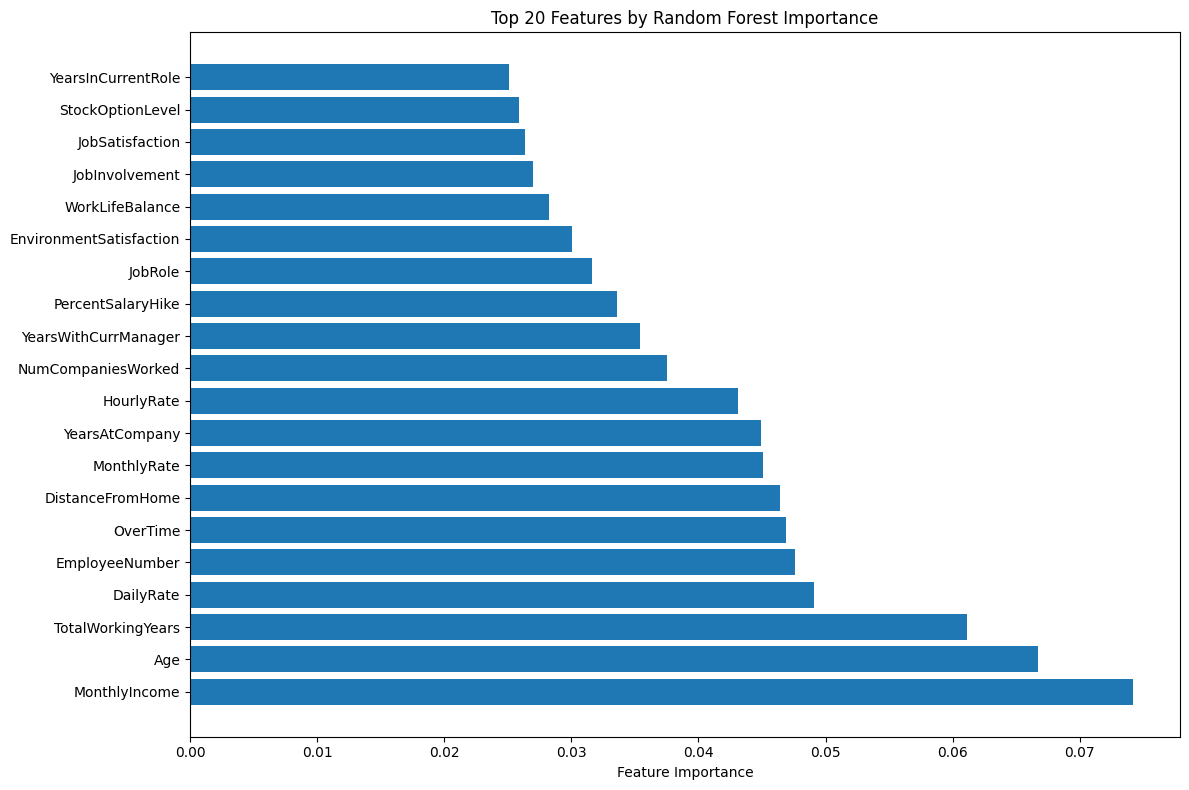

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


print("\n" + "="*60)
print("STEP 4: TREE-BASED FEATURE IMPORTANCE")
print("="*60)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train a Random Forest to get feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)

# Get feature importance
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 features by Random Forest Importance:")
print(feature_importance_df.head(15))

# Visualize
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'].head(20), 
         feature_importance_df['importance'].head(20))
plt.xlabel('Feature Importance')
plt.title('Top 20 Features by Random Forest Importance')
plt.tight_layout()
plt.show()

In [16]:
print("\n" + "="*60)
print("STEP 5: COMBINED FEATURE RANKING")
print("="*60)

# Normalize scores to 0-1 range
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

combined_df = pd.DataFrame({'feature': X.columns})
combined_df['mi_score_norm'] = scaler.fit_transform(mi_scores_df['mi_score'].values.reshape(-1, 1))
combined_df['rf_importance_norm'] = scaler.fit_transform(feature_importance_df['importance'].values.reshape(-1, 1))

# Calculate combined score (average of normalized scores)
combined_df['combined_score'] = (combined_df['mi_score_norm'] + 
                                  combined_df['rf_importance_norm']) / 2
combined_df = combined_df.sort_values('combined_score', ascending=False)

print("\nTop 15 features by Combined Score:")
print(combined_df.head(15))


STEP 5: COMBINED FEATURE RANKING

Top 15 features by Combined Score:
                    feature  mi_score_norm  rf_importance_norm  combined_score
0                       Age       1.000000            1.000000        1.000000
1            BusinessTravel       0.723312            0.894037        0.808674
2                 DailyRate       0.716084            0.813905        0.764994
3                Department       0.657961            0.642726        0.650344
4          DistanceFromHome       0.648330            0.621800        0.635065
5                 Education       0.587785            0.611379        0.599582
6            EducationField       0.525585            0.604539        0.565062
7            EmployeeNumber       0.518851            0.585662        0.552256
8   EnvironmentSatisfaction       0.487739            0.583413        0.535576
9                    Gender       0.402911            0.557326        0.480119
10               HourlyRate       0.397506            0.47786

In [17]:
from sklearn.metrics import roc_auc_score


print("\n" + "="*60)
print("STEP 6: SELECT TOP K FEATURES AND EVALUATE")
print("="*60)

# Test different numbers of features
k_values = [10, 15, 20, 25]
results = []

for k in k_values:
    # Select top k features
    top_features = combined_df.head(k)['feature'].tolist()
    
    X_train_selected = X_train[top_features]
    X_test_selected = X_test[top_features]
    
    # Train model
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    rf_model.fit(X_train_selected, y_train)
    
    # Evaluate
    y_pred = rf_model.predict(X_test_selected)
    y_pred_proba = rf_model.predict_proba(X_test_selected)[:, 1]
    
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'k': k,
        'auc': auc_score,
        'features': top_features
    })
    
    print(f"\nWith top {k} features: AUC = {auc_score:.4f}")

# Find best k
best_result = max(results, key=lambda x: x['auc'])
print(f"\n{'='*60}")
print(f"BEST PERFORMANCE: {best_result['k']} features with AUC = {best_result['auc']:.4f}")
print(f"\nSelected features:")
for i, feat in enumerate(best_result['features'], 1):
    print(f"{i:2d}. {feat}")


STEP 6: SELECT TOP K FEATURES AND EVALUATE

With top 10 features: AUC = 0.6466

With top 15 features: AUC = 0.6976

With top 20 features: AUC = 0.7996

With top 25 features: AUC = 0.7854

BEST PERFORMANCE: 20 features with AUC = 0.7996

Selected features:
 1. Age
 2. BusinessTravel
 3. DailyRate
 4. Department
 5. DistanceFromHome
 6. Education
 7. EducationField
 8. EmployeeNumber
 9. EnvironmentSatisfaction
10. Gender
11. HourlyRate
12. JobInvolvement
13. JobLevel
14. JobRole
15. JobSatisfaction
16. MaritalStatus
17. MonthlyIncome
18. MonthlyRate
19. NumCompaniesWorked
20. OverTime


# End of Feature selection